# RFM Segmentation
---

In [4]:
import pandas as pd
import numpy as np
import datetime as dt
df_clean = pd.read_csv("../data/processed/cleaned_online_retail.csv")

# Convert InvoiceDate back to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [5]:
max_date = df_clean["InvoiceDate"].max()
max_date

Timestamp('2011-12-09 12:50:00')

In [6]:
reference_date = max_date + dt.timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [7]:
rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [8]:
rfm.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


In [13]:
#Scored each metric from 1–4
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [10]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,4,4,244
12347.0,2,8,5633.32,4,4,4,444
12348.0,75,5,2019.40,3,3,3,333
12349.0,19,4,4428.69,4,3,4,434
12350.0,310,1,334.40,2,1,1,211


In [11]:
def segment_customer(row):
    if row["R_Score"] == 4 and row["F_Score"] >= 3:
        return "Champions"
    elif row["F_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"
    else:
        return "Potential"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm["Segment"].value_counts()

Segment
At Risk            2046
Loyal Customers    1766
Champions          1174
Potential           895
Name: count, dtype: int64

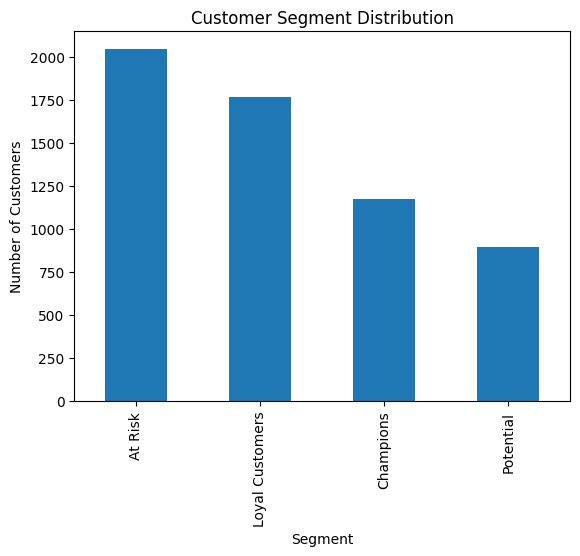

In [12]:
import matplotlib.pyplot as plt

segment_counts = rfm["Segment"].value_counts()

plt.figure()
segment_counts.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.ylabel("Number of Customers")
plt.show()

## RFM Segmentation Insights
---

### 1. Customer Value Distribution

The RFM analysis highlights a clear differentiation in purchasing behavior across customer segments. A relatively small segment identified as **Champions** demonstrates high recency, strong purchase frequency, and significant monetary contribution.  

This segment represents the most valuable customer base and plays a critical role in sustaining overall revenue and long-term business growth.

### 2. Loyal Customer Base

The **Loyal Customers** segment consists of customers with consistent purchasing frequency and moderate-to-high spending levels.  

Although they may not always be the most recent buyers, they contribute stable and predictable revenue. This group represents strong retention potential and offers opportunities for upselling and cross-selling initiatives.

### 3. At-Risk Segment

Customers classified as **At Risk** exhibit low recency and declining purchase frequency.  

This pattern indicates reduced engagement and a heightened probability of churn if proactive retention measures are not implemented.

### 4. Revenue Concentration Across Segments

Revenue distribution across segments is uneven, with high-value customers contributing a disproportionate share of total sales.  

This reinforces the strategic importance of focused retention efforts and personalized engagement strategies for top-performing customer segments.

## Strategic Recommendations
---

### 1. Retain Champions
- Implement structured loyalty programs  
- Offer exclusive access to products or services  
- Provide personalized rewards and premium benefits  

### 2. Nurture Loyal Customers
- Introduce product bundling strategies  
- Deliver personalized product recommendations  
- Run targeted promotional campaigns to increase basket size  

### 3. Re-Engage At-Risk Customers
- Launch win-back campaigns with tailored discount incentives  
- Send reminder and reactivation email sequences  
- Conduct personalized outreach to rebuild engagement  

### 4. Segment-Based Marketing Allocation
- Prioritize retention investment toward high-value segments  
- Optimize marketing spend by testing cost-effective reactivation campaigns  
- Continuously monitor segment movement and adjust strategies accordingly  
